<div style="float: right;">
  <a href="../de/sampling_bias.html" style="margin-left: 10px;">Deutsch</a>
  <a href="../en/sampling_bias.html">English</a>
</div>

# 2. Stichprobenverzerrung (Sampling Bias)

### Was ist eine Stichprobenverzerrung?

Stell dir vor, du willst die Lesegewohnheiten einer ganzen Stadt untersuchen und
verteilst dazu Fragebögen in der öffentlichen Bibliothek. Fast jeder, den du
triffst, liest regelmäßig — deine Daten sehen großartig aus! Aber wenn du diese
Ergebnisse nutzt, um die Lesegewohnheiten *der ganzen Stadt* vorherzusagen, wird
dein Modell zu optimistisch sein, weil du nur Menschen befragt hast, die bereits
in der Bibliothek waren. Menschen, die nie in eine Bibliothek gehen, kamen in
deinen Daten gar nicht vor.

Das ist eine **Stichprobenverzerrung (Sampling Bias)**: wenn die Daten, mit denen
ein Modell trainiert wird, nicht genau die reale Population widerspiegeln, auf die
das Modell später angewendet wird. Manche Gruppen kommen *häufiger* vor, als sie
sollten (Überrepräsentation), während andere kaum auftauchen (Unterrepräsentation).
Das Modell lernt die Muster der Mehrheitsgruppe gut, hat aber Schwierigkeiten,
sobald es auf Gruppen trifft, die es im Training kaum gesehen hat.

In diesem Tutorial versuchen wir, den **genauen Stundenlohn** einer Person aus
Bildung, Berufserfahrung, Wochenstunden und Betriebszugehörigkeit vorherzusagen.
Wir trainieren ein Modell mit einer repräsentativen Stichprobe aller Altersgruppen
und ein zweites mit Daten, die **nur junge Arbeitnehmer** enthalten. Da
Berufserfahrung der Haupttreiber für den Lohn ist und junge Arbeitnehmer wenig
davon haben, lernt das verzerrte Modell nie, wie Arbeitnehmer mit viel Erfahrung
aussehen. Trifft es zur Testzeit auf sie, unterschätzt es ihren Lohn drastisch.

In [1]:
# Pakete installieren, wenn der Code in JupyterLite (Pyodide) über Thebe läuft.
try:
    import micropip
    await micropip.install(['scikit-learn', 'ipywidgets', 'matplotlib', 'pandas', 'numpy'])
except ImportError:
    pass

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import ipywidgets as widgets
from IPython.display import display, clear_output
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

def rmse(y_true, y_pred):
    """Root Mean Squared Error (niedriger ist besser)."""
    return np.sqrt(mean_squared_error(y_true, y_pred))

# ── Synthetische Lohn-Population ───────────────────────────────────────────
n = 5000
age            = np.random.normal(41, 17, n).clip(16, 67).round().astype(int)
education      = np.random.normal(14, 2.5, n).clip(8, 20).round().astype(int)
experience     = np.maximum(0, np.maximum(0, age - education - 6) +
                            np.random.normal(0, 9.5, n).clip(-15, 15))
hours_per_week = np.random.normal(40, 8, n).clip(20, 60)
tenure         = np.minimum(experience, np.random.exponential(5, n).clip(0, 25))

wage = (
    5.0
    + 0.10 * age        # Erfahrung ist der Haupttreiber
    + 0.20 * tenure
    + 0.15 * education
    + 0.1 * hours_per_week
    + np.random.normal(0, 3, n)
).clip(10, None)

df = pd.DataFrame({
    'age':            age,
    'education':      education,
    'experience':     experience,
    'hours_per_week': hours_per_week,
    'tenure':         tenure,
    'wage':           wage,
})

def age_group(a):
    if a < 30:  return 'Unter 30'
    if a <= 54: return '30–54'
    return '55 und älter'

df['age_group'] = df['age'].apply(age_group)
GROUP_ORDER  = ['Unter 30', '30–54', '55 und älter']
GROUP_COLORS = {'Unter 30': 'mediumpurple', '30–54': 'steelblue', '55 und älter': 'darkorange'}

# Das Alter wird NICHT als Variable verwendet. Das Modell sieht nur Bildung,
# Erfahrung, Wochenstunden und Betriebszugehörigkeit. Es muss die Lohnmuster
# allein daraus lernen.
feature_cols = ['education', 'hours_per_week', 'experience', 'tenure']

# Feste, ausgewogene Testmenge: bleibt über alle Experimente hinweg konstant
df_full_train, df_test = train_test_split(df, test_size=0.3, random_state=42)
df_test = df_test.copy()

KEEP_FRACTION = 0.0   # 0% der mittelalten und älteren Arbeitnehmer behalten (nur junge Arbeitnehmer)

def make_biased_sample(df_tr, keep_fraction):
    """
    Behält ALLE jungen Arbeitnehmer (unter 30), aber nur einen zufälligen
    Anteil der mittelalten und älteren Arbeitnehmer.
    keep_fraction=1.0 bedeutet keine Verzerrung; 0.0 bedeutet nur junge Arbeitnehmer.
    """
    young  = df_tr[df_tr['age'] < 30]
    middle = df_tr[(df_tr['age'] >= 30) & (df_tr['age'] <= 54)].sample(frac=keep_fraction, random_state=42)
    older  = df_tr[df_tr['age'] > 54].sample(frac=keep_fraction, random_state=42)
    return pd.concat([young, middle, older]).reset_index(drop=True)

---

## Die wahre Population

Bevor wir eine Verzerrung einführen, schauen wir uns die Lohnverteilung über die
Altersgruppen an. Erfahrung sammelt sich mit dem Alter an, und da Erfahrung in
unserem Modell der Haupttreiber für den Lohn ist, verdienen ältere Arbeitnehmer
im Schnitt deutlich mehr.

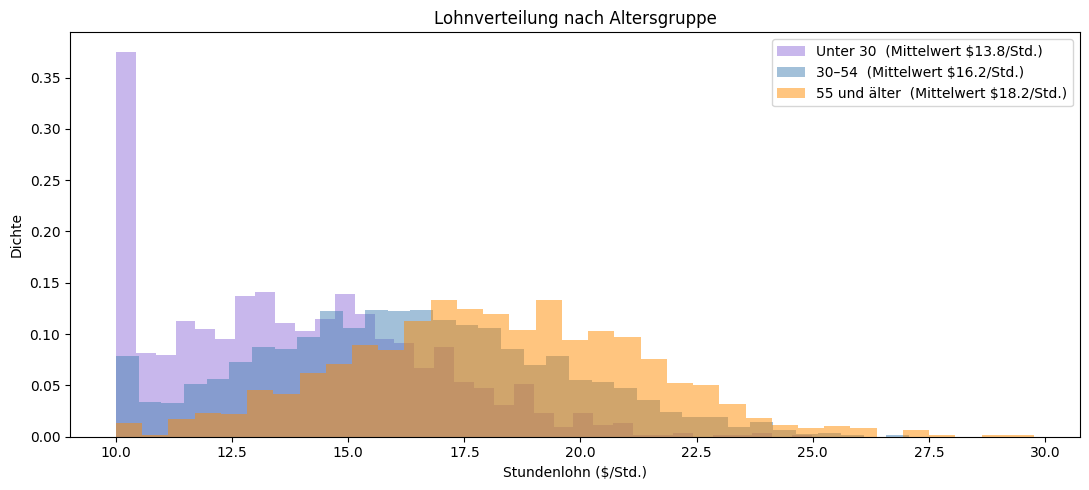

Mittlerer Lohn in der Gesamtpopulation:
  Unter 30          : $13.8/Std.  (n=1226)
  30–54             : $16.2/Std.  (n=2721)
  55 und älter      : $18.2/Std.  (n=1053)


In [3]:
fig, ax = plt.subplots(figsize=(11, 5))

for group in GROUP_ORDER:
    wages = df.loc[df['age_group'] == group, 'wage']
    ax.hist(wages, bins=35, alpha=0.5, color=GROUP_COLORS[group],
             label=f'{group}  (Mittelwert ${wages.mean():.1f}/Std.)', density=True)

ax.set_xlabel('Stundenlohn ($/Std.)')
ax.set_ylabel('Dichte')
ax.set_title('Lohnverteilung nach Altersgruppe')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

print("Mittlerer Lohn in der Gesamtpopulation:")
for g in GROUP_ORDER:
    subset = df[df['age_group'] == g]
    print(f"  {g:<18}: ${subset['wage'].mean():.1f}/Std.  (n={len(subset)})")

Die drei Verteilungen sind klar voneinander getrennt: Junge Arbeitnehmer ballen
sich um \$14/Std., mittelalte um \$16/Std. und ältere oberhalb von \$18/Std. Ein
Modell, das nur junge Arbeitnehmer gesehen hat, hat keine Ahnung, dass Löhne diese
Höhen erreichen können.

## Eine verzerrte Stichprobe erstellen

Wir erzeugen nun eine verzerrte Trainingsmenge, indem wir **alle** jungen
Arbeitnehmer, aber **keine** mittelalten oder älteren Arbeitnehmer behalten. Das
simuliert ein Datenerhebungsszenario wie etwa eine Online-Umfrage, die nur
Berufseinsteiger erreicht hat.

In [4]:
df_biased_train = make_biased_sample(df_full_train, keep_fraction=KEEP_FRACTION)

print("Zusammensetzung der Trainingsmenge vor und nach der Stichprobenverzerrung")
print("=" * 60)
print(f"{'Altersgruppe':<18} {'Original':>10} {'Verzerrt':>8}  {'% behalten':>10}")
print("-" * 60)
for g in GROUP_ORDER:
    orig = (df_full_train['age_group'] == g).sum()
    bias = (df_biased_train['age_group'] == g).sum()
    pct  = 100 * bias / orig if orig > 0 else 0
    print(f"{g:<18} {orig:>10} {bias:>8}  {pct:>9.0f}%")

print(f"\nMittlerer Lohn in ausgewogener Trainingsmenge: ${df_full_train['wage'].mean():.1f}/Std.")
print(f"Mittlerer Lohn in verzerrter Trainingsmenge:    ${df_biased_train['wage'].mean():.1f}/Std.")

Zusammensetzung der Trainingsmenge vor und nach der Stichprobenverzerrung
Altersgruppe         Original Verzerrt  % behalten
------------------------------------------------------------
Unter 30                  868      868        100%
30–54                    1884        0          0%
55 und älter              748        0          0%

Mittlerer Lohn in ausgewogener Trainingsmenge: $16.0/Std.
Mittlerer Lohn in verzerrter Trainingsmenge:    $13.8/Std.


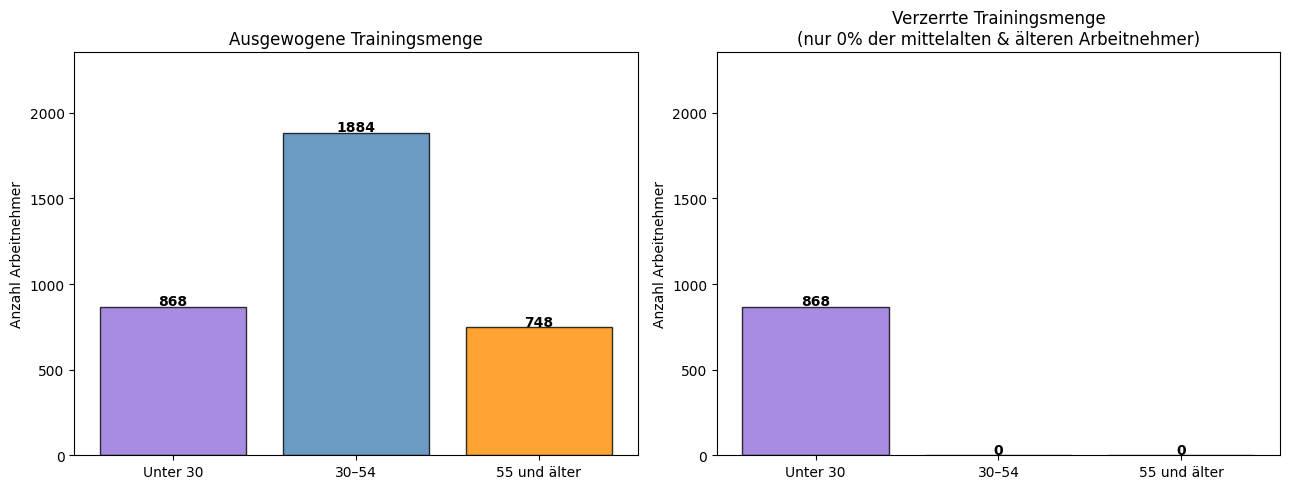

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, df_plot, title in [
    (axes[0], df_full_train,   'Ausgewogene Trainingsmenge'),
    (axes[1], df_biased_train, f'Verzerrte Trainingsmenge\n(nur {int(KEEP_FRACTION*100)}% der mittelalten & älteren Arbeitnehmer)'),
]:
    counts = {g: (df_plot['age_group'] == g).sum() for g in GROUP_ORDER}
    vals   = [counts[g] for g in GROUP_ORDER]
    colors = [GROUP_COLORS[g] for g in GROUP_ORDER]
    ax.bar(GROUP_ORDER, vals, color=colors, edgecolor='black', alpha=0.8)
    ax.set_ylabel('Anzahl Arbeitnehmer')
    ax.set_title(title)
    ax.set_ylim(0, max((df_full_train['age_group'] == g).sum() for g in GROUP_ORDER) * 1.25)
    for i, v in enumerate(vals):
        ax.text(i, v + 10, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

Die verzerrte Menge enthält nur junge Arbeitnehmer. Ihr mittlerer Lohn liegt bei
etwa \$12/Std. Das auf diesen Daten trainierte Modell wird nie lernen, dass Löhne
\$20–30/Std. erreichen können.

## Training zweier Modelle

Wir verwenden einen **Decision-Tree-Regressor**: ein Modell, das Wenn-Dann-Regeln
lernt, um eine numerische Zielgröße vorherzusagen. Zum Beispiel: *"Hat dieser
Arbeitnehmer mehr als 15 Jahre Erfahrung? Falls ja, sage einen höheren Lohn
voraus."* Jede Regel wird ausschließlich aus den Trainingsbeispielen gelernt, die
das Modell gesehen hat. Entscheidend ist: Ein Decision Tree rät **nicht** über
seinen Trainingsbereich hinaus: Hat er nur Arbeitnehmer mit \$10–20/Std. gesehen,
hat er keine Grundlage, um für irgendjemanden \$25/Std. vorherzusagen. Andere
Modelle könnten flexibler sein und Löhne anhand von Faktoren wie Berufserfahrung
extrapolieren, hätten aber trotzdem Schwierigkeiten, die richtigen Muster allein
aus den Daten junger Arbeitnehmer zu lernen.

- **Ausgewogenes Modell**: trainiert auf der vollständigen, repräsentativen Trainingsmenge
- **Verzerrtes Modell**: trainiert nur auf jungen Arbeitnehmern (keine mittelalten oder älteren)

Beide Modelle werden dann auf derselben Testmenge getestet, die die wahre
Altersverteilung der Population widerspiegelt.

In [6]:
# Ausgewogenes Modell. Sieht alle Altersgruppen in ihren wahren Anteilen
tree_balanced = DecisionTreeRegressor(max_depth=4, random_state=42)
tree_balanced.fit(df_full_train[feature_cols], df_full_train['wage'])

# Verzerrtes Modell, nur mit jungen Arbeitnehmern trainiert
tree_biased = DecisionTreeRegressor(max_depth=4, random_state=42)
tree_biased.fit(df_biased_train[feature_cols], df_biased_train['wage'])

# Vorhersagen als neue Spalten in der Testtabelle speichern
df_test['pred_balanced'] = tree_balanced.predict(df_test[feature_cols])
df_test['pred_biased']   = tree_biased.predict(df_test[feature_cols])

# Gesamt-RMSE: durchschnittlicher Vorhersagefehler (niedriger ist besser)
print(f"Gesamter Vorhersagefehler RMSE (niedriger ist besser):")
print(f"  Ausgewogenes Modell: {rmse(df_test['wage'], df_test['pred_balanced']):.2f} $/Std.")
print(f"  Verzerrtes Modell:   {rmse(df_test['wage'], df_test['pred_biased']):.2f} $/Std.")
print()
print(f"Mittlerer vorhergesagter Lohn vs. tatsächlich:")
print(f"  Tatsächlich:          ${df_test['wage'].mean():.1f}/Std.")
print(f"  Ausgewogenes Modell:  ${df_test['pred_balanced'].mean():.1f}/Std.")
print(f"  Verzerrtes Modell:    ${df_test['pred_biased'].mean():.1f}/Std.  <-- unterschätzt die Löhne")

Gesamter Vorhersagefehler RMSE (niedriger ist besser):
  Ausgewogenes Modell: 3.11 $/Std.
  Verzerrtes Modell:   3.71 $/Std.

Mittlerer vorhergesagter Lohn vs. tatsächlich:
  Tatsächlich:          $16.1/Std.
  Ausgewogenes Modell:  $16.0/Std.
  Verzerrtes Modell:    $14.5/Std.  <-- unterschätzt die Löhne


Der Gesamtfehler des verzerrten Modells ist deutlich größer. Aber die Gesamtzahl
verschleiert, *bei wem* das Modell danebenliegt.

## Wie jede Gruppe vorhergesagt wird

Für jede Altersgruppe vergleichen wir den **tatsächlichen mittleren Lohn**, die
Vorhersage des **ausgewogenen Modells** und die Vorhersage des **verzerrten
Modells**.

In [7]:
print(f"{'Altersgruppe':<18} {'Tatsächlich':>12} {'Ausgewogen':>11} {'Verzerrt':>9}  {'RMSE verzerrt':>14}")
print("-" * 68)
for g in GROUP_ORDER:
    subset = df_test[df_test['age_group'] == g]
    actual   = subset['wage'].mean()
    balanced = subset['pred_balanced'].mean()
    biased   = subset['pred_biased'].mean()
    err      = rmse(subset['wage'], subset['pred_biased'])
    print(f"{g:<18} ${actual:>10.1f} ${balanced:>9.1f} ${biased:>7.1f}  {err:>13.2f} $/Std.")

Altersgruppe        Tatsächlich  Ausgewogen  Verzerrt   RMSE verzerrt
--------------------------------------------------------------------
Unter 30           $      14.0 $     14.4 $   13.8           2.87 $/Std.
30–54              $      16.3 $     16.2 $   14.6           3.62 $/Std.
55 und älter       $      18.2 $     17.4 $   14.8           4.68 $/Std.


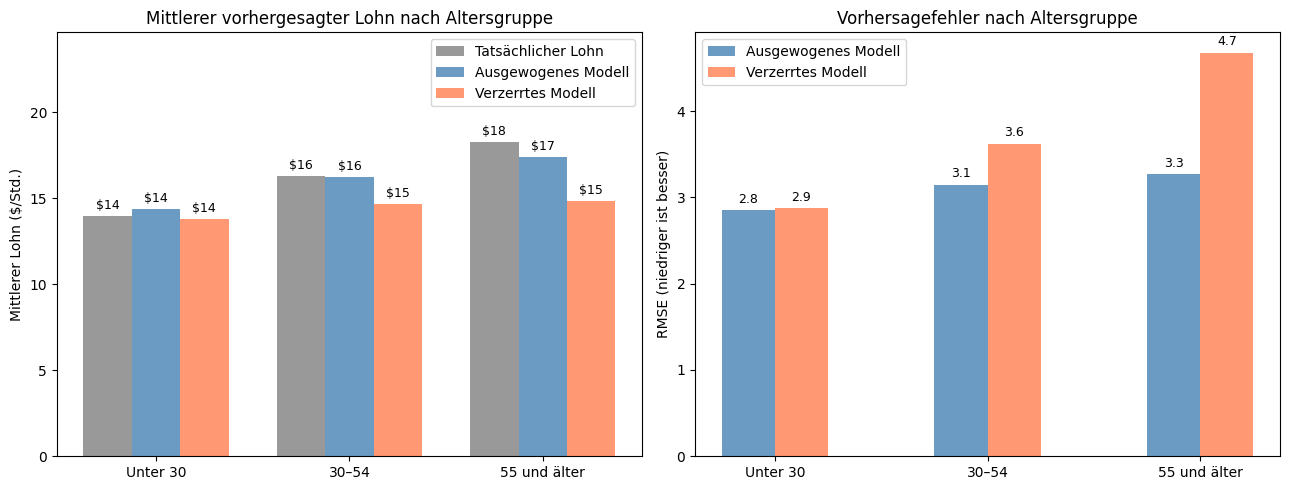

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

x     = np.arange(len(GROUP_ORDER))
width = 0.25

actual_means   = [df_test[df_test['age_group'] == g]['wage'].mean()          for g in GROUP_ORDER]
balanced_means = [df_test[df_test['age_group'] == g]['pred_balanced'].mean() for g in GROUP_ORDER]
biased_means   = [df_test[df_test['age_group'] == g]['pred_biased'].mean()   for g in GROUP_ORDER]

# ── Links: mittlerer vorhergesagter Lohn vs. tatsächlich ────────────────────
ba = axes[0].bar(x - width, actual_means,   width, label='Tatsächlicher Lohn',  color='gray',      alpha=0.8)
bb = axes[0].bar(x,          balanced_means, width, label='Ausgewogenes Modell', color='steelblue', alpha=0.8)
bc = axes[0].bar(x + width,  biased_means,   width, label='Verzerrtes Modell',   color='coral',     alpha=0.8)
axes[0].set_ylabel('Mittlerer Lohn ($/Std.)')
axes[0].set_title('Mittlerer vorhergesagter Lohn nach Altersgruppe')
axes[0].set_xticks(x)
axes[0].set_xticklabels(GROUP_ORDER)
axes[0].legend()
axes[0].set_ylim(0, max(actual_means) * 1.35)
for bar_group in [ba, bb, bc]:
    for bar in bar_group:
        h = bar.get_height()
        axes[0].annotate(f'${h:.0f}', xy=(bar.get_x() + bar.get_width() / 2, h),
                         xytext=(0, 3), textcoords='offset points',
                         ha='center', va='bottom', fontsize=9)

# ── Rechts: RMSE nach Gruppe ─────────────────────────────────────────────────
rmse_bal = [rmse(df_test[df_test['age_group'] == g]['wage'],
                 df_test[df_test['age_group'] == g]['pred_balanced']) for g in GROUP_ORDER]
rmse_bia = [rmse(df_test[df_test['age_group'] == g]['wage'],
                 df_test[df_test['age_group'] == g]['pred_biased'])   for g in GROUP_ORDER]

rb = axes[1].bar(x - width/2, rmse_bal, width, label='Ausgewogenes Modell', color='steelblue', alpha=0.8)
rc = axes[1].bar(x + width/2, rmse_bia, width, label='Verzerrtes Modell',   color='coral',     alpha=0.8)
axes[1].set_ylabel('RMSE (niedriger ist besser)')
axes[1].set_title('Vorhersagefehler nach Altersgruppe')
axes[1].set_xticks(x)
axes[1].set_xticklabels(GROUP_ORDER)
axes[1].legend()
for bar_group in [rb, rc]:
    for bar in bar_group:
        h = bar.get_height()
        axes[1].annotate(f'{h:.1f}', xy=(bar.get_x() + bar.get_width() / 2, h),
                         xytext=(0, 3), textcoords='offset points',
                         ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

Das ausgewogene Modell (blau) folgt den tatsächlichen Löhnen für alle drei
Gruppen recht genau. Das verzerrte Modell (koralle) bleibt für *alle* nahe am
Lohnniveau junger Arbeitnehmer hängen: Es ist nie auf Arbeitnehmer mit viel
Erfahrung gestoßen und hat daher keine Möglichkeit, vorherzusagen, dass ihr Lohn
$20–30/Std. betragen kann. Je älter die Gruppe, desto größer der Fehler.

## Interaktiver Explorer

Wie stark spielt das Ausmaß der Unterrepräsentation eine Rolle? Nutze den Regler,
um zu steuern, welcher Anteil der mittelalten und älteren Arbeitnehmer in den
Trainingsdaten verbleibt, und klicke dann auf **Trainieren & Auswerten**, um zu
sehen, wie sich die Vorhersagen verändern.

- **100 %**: keine Verzerrung, voll repräsentative Trainingsdaten
- **5 %**: starke Verzerrung, junge Arbeitnehmer dominieren
- **0 %**: extrem: nur junge Arbeitnehmer (Modell sagt für alle Löhne wie für junge Arbeitnehmer voraus)

In [9]:
slider = widgets.IntSlider(
    value=0, min=0, max=100, step=5,
    description='% mittelalt/älter behalten:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='450px'),
    continuous_update=False,
)
button      = widgets.Button(description='Trainieren & Auswerten', button_style='primary',
                             icon='play', layout=widgets.Layout(width='200px', height='36px'))
output_area = widgets.Output()

def run_experiment(_):
    keep = slider.value / 100.0
    with output_area:
        clear_output(wait=True)

        df_b = make_biased_sample(df_full_train, keep_fraction=keep)
        tree = DecisionTreeRegressor(max_depth=4, random_state=42)
        tree.fit(df_b[feature_cols], df_b['wage'])

        results = df_test[['age_group', 'wage']].copy()
        results['pred'] = tree.predict(df_test[feature_cols])

        print(f"Behaltener Anteil: {int(keep*100)}%  |  Trainingsgröße: {len(df_b)}  "
              f"|  Mittlerer Lohn im Training: ${df_b['wage'].mean():.1f}/Std.")
        print("=" * 68)
        print(f"{'Altersgruppe':<18} {'Tatsächlich':>12} {'Ausgewogen':>11} {'Dieses Modell':>14}  {'RMSE':>8}")
        print("-" * 68)
        for g in GROUP_ORDER:
            sub      = results[results['age_group'] == g]
            actual   = sub['wage'].mean()
            balanced = df_test[df_test['age_group'] == g]['pred_balanced'].mean()
            pred     = sub['pred'].mean()
            err      = rmse(sub['wage'], sub['pred'])
            print(f"{g:<18} ${actual:>10.1f} ${balanced:>9.1f} ${pred:>12.1f}  {err:>7.2f} $/Std.")

        fig, axes = plt.subplots(1, 2, figsize=(13, 4))
        x     = np.arange(len(GROUP_ORDER))
        width = 0.25

        ra = [df_test[df_test['age_group'] == g]['wage'].mean()          for g in GROUP_ORDER]
        rb = [df_test[df_test['age_group'] == g]['pred_balanced'].mean() for g in GROUP_ORDER]
        rm = [results[results['age_group'] == g]['pred'].mean()          for g in GROUP_ORDER]

        axes[0].bar(x - width, ra, width, label='Tatsächlich',       color='gray',      alpha=0.8)
        axes[0].bar(x,          rb, width, label='Ausgewogenes Modell', color='steelblue', alpha=0.8)
        axes[0].bar(x + width,  rm, width, label='Dieses Modell',       color='coral',     alpha=0.8)
        axes[0].set_ylabel('Mittlerer Lohn ($/Std.)')
        axes[0].set_title(f'Mittlerer vorhergesagter Lohn  (behalten = {int(keep*100)}%)')
        axes[0].set_xticks(x)
        axes[0].set_xticklabels(GROUP_ORDER)
        axes[0].legend()

        rmse_b = [rmse(df_test[df_test['age_group'] == g]['wage'],
                       df_test[df_test['age_group'] == g]['pred_balanced']) for g in GROUP_ORDER]
        rmse_m = [rmse(results[results['age_group'] == g]['wage'],
                       results[results['age_group'] == g]['pred'])          for g in GROUP_ORDER]

        axes[1].bar(x - width/2, rmse_b, width, label='Ausgewogenes Modell', color='steelblue', alpha=0.8)
        axes[1].bar(x + width/2, rmse_m, width, label='Dieses Modell',       color='coral',     alpha=0.8)
        axes[1].set_ylabel('RMSE ($/Std.)')
        axes[1].set_title(f'Vorhersagefehler nach Altersgruppe  (behalten = {int(keep*100)}%)')
        axes[1].set_xticks(x)
        axes[1].set_xticklabels(GROUP_ORDER)
        axes[1].legend()

        plt.tight_layout()
        plt.show()

button.on_click(run_experiment)
display(widgets.VBox([slider, button, output_area]))

## Wichtige Erkenntnisse

- **Der Gesamtfehler verschleiert das Problem**: Das verzerrte Modell wirkt
  insgesamt einigermaßen genau, weil es bei den vielen jungen Arbeitnehmern in der
  Testmenge richtigliegt. Erst die Auswertung auf Gruppenebene zeigt, wie stark es
  bei älteren Arbeitnehmern versagt.
- **Das verzerrte Modell bleibt bei Löhnen junger Arbeitnehmer hängen**: Da es nur
  mit Arbeitnehmern trainiert wurde, die \$10–16/Std. verdienen, sind seine
  Vorhersagen auf diesen Bereich begrenzt. Trifft es auf eine 50-jährige Person
  mit 25 Jahren Erfahrung, sagt es etwa \$12–14/Std. voraus, obwohl der
  tatsächliche Lohn näher an \$22/Std. liegt.
- **Ältere Arbeitnehmer trifft es am härtesten**: Je weiter eine Altersgruppe von
  den Trainingsdaten entfernt ist, desto größer der Vorhersagefehler. Die Gruppe
  55+, die am meisten verdient, leidet unter der stärksten Unterschätzung.
- **Mehr junge Daten machen es schlimmer**: Würde man der Trainingsmenge weitere
  junge Arbeitnehmer hinzufügen, würde das die Verzerrung verstärken, nicht
  verringern. Entscheidend ist, *wer* in den Daten enthalten ist, nicht nur wie
  groß der Datensatz ist.
- **Der Regler zeigt den Kipppunkt**: Nutze den interaktiven Explorer oben, um
  herauszufinden, ab welchem behaltenen Prozentsatz sich das verzerrte Modell wie
  das ausgewogene zu verhalten beginnt. Beachte, wie schnell sich die Vorhersagen
  verbessern, sobald auch nur ein kleiner Anteil älterer Arbeitnehmer wieder
  hinzugefügt wird.